In [49]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
from scripts.run_experiments import run_experiment
from scripts.experiment_utils import generate_experiments

In [51]:
base_config = {
    # Experiment
    "experiment": "torus",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "torus",
    "batch_size": 64,
    "rotation": "random",
    "translation": None,
    "deformation_amp": 0.0,
    "n_times": 9000,
    "major_radius": 4,
    "minor_radius": 1.5,
    "filled": False,
    "embedding_dim": 10,
    "noise_var": 0.001,

    # Model
    'model_type': 'EuclideanVAE',
    'data_dim': 10,
    'latent_dim': 3,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [100, 100, 100],
    'decoder_widths': [100, 100, 100],

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 10,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'dim_topo_loss': 0,
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.0,  # Weight for KL loss
    'gamma': 0.0,  # Weight for topological loss

    # Curvature computation
    "compute_true_curv": False,
    "compute_learned_curv": False,
    "n_plot_points": 2000,
    "n_points_emp_curv": 8000,  # number of points to compute the empirical curvature
    "n_points_pullback_curv": 1500,  # number of points to compute the pullback (true/learned). Should be 1000-2000.
    "k": 440,
    "smoothing": False,

    # Persistent homology
    "persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1, 2]
}

param_grid = {
    "alpha": [1] * 1 + [1, 1, 0] * 3,
    "gamma": [0] + [1, 1000, 1] * 3,
    "deformation_amp": [3] * 10,
    "dim_topo_loss": [0] + [0] * 3 + [1] * 3 + [2] * 3,
}


all_configs = generate_experiments(base_config, param_grid)



Running exp00_torus. 
Description: alpha=1, gamma=0, deformation_amp=3, dim_topo_loss=0
--------------------------------------------------------------------------------------


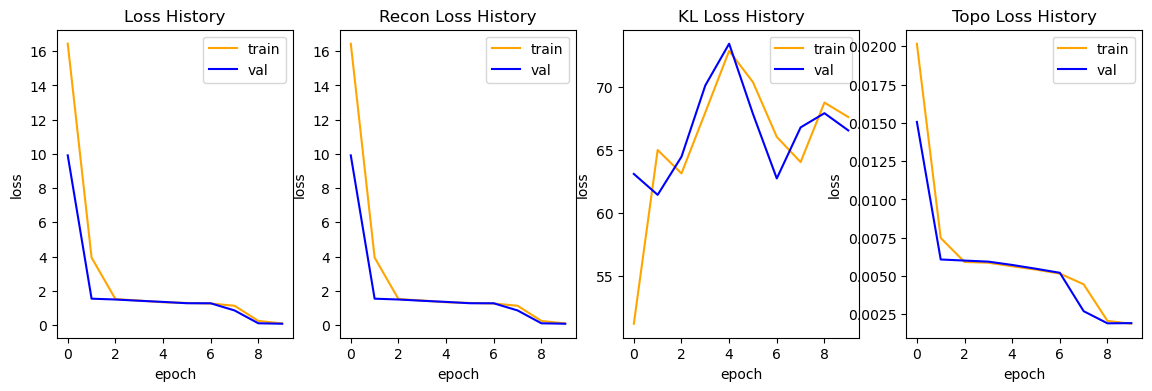

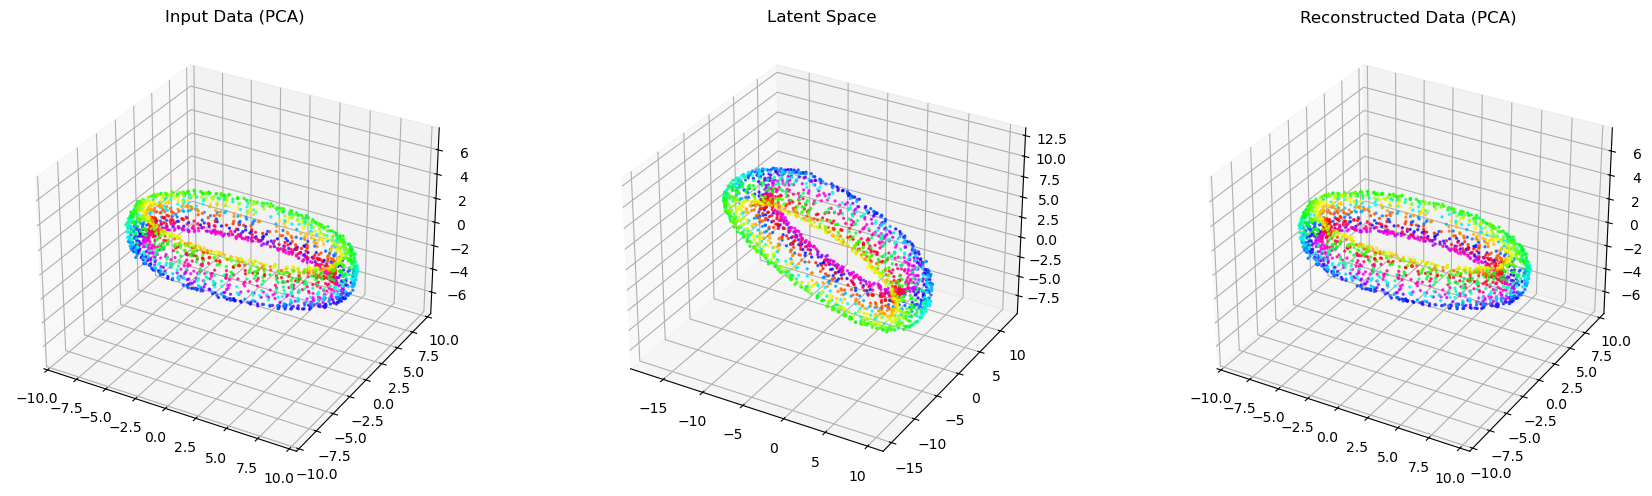

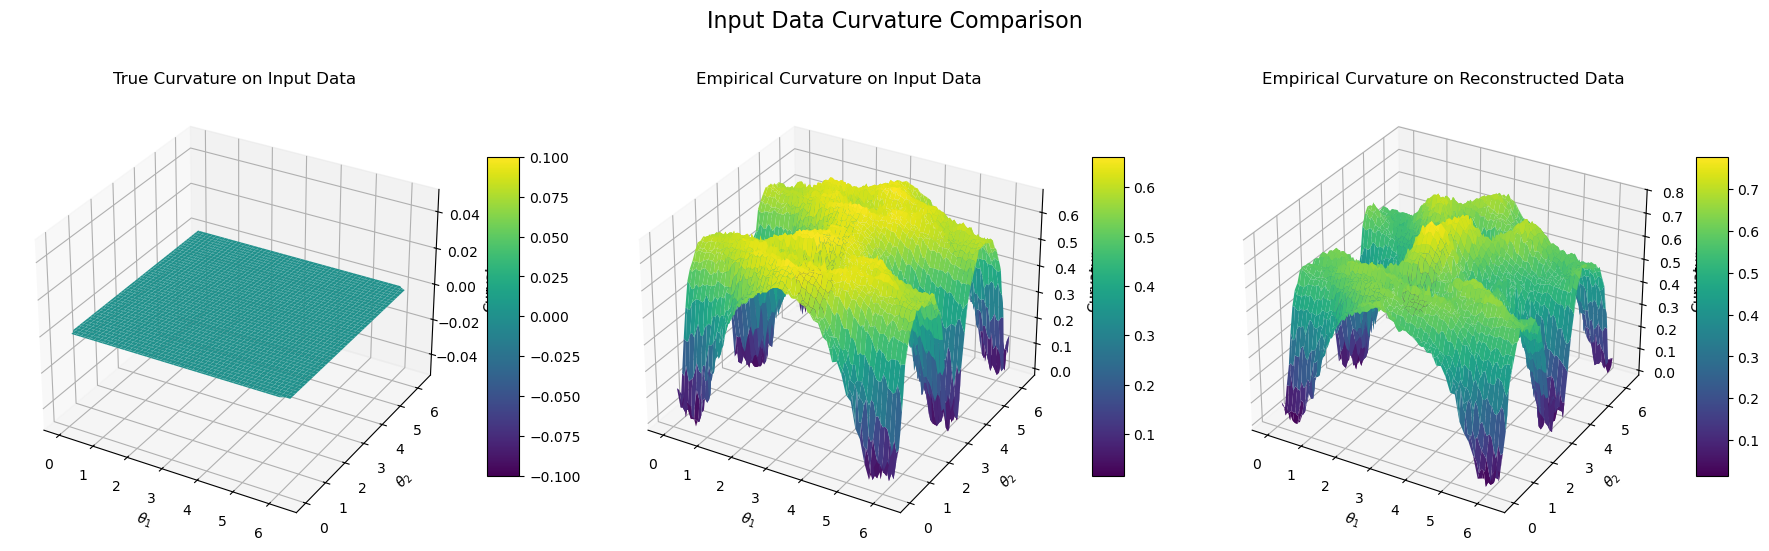

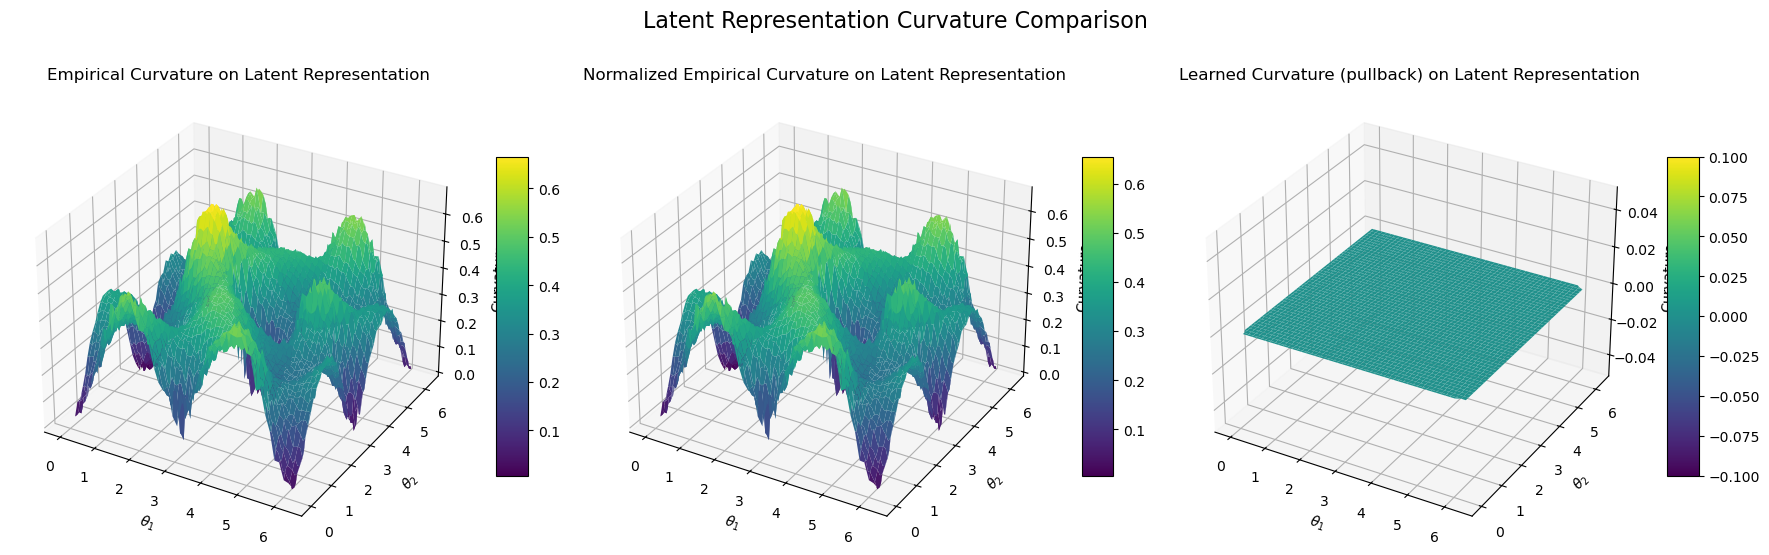

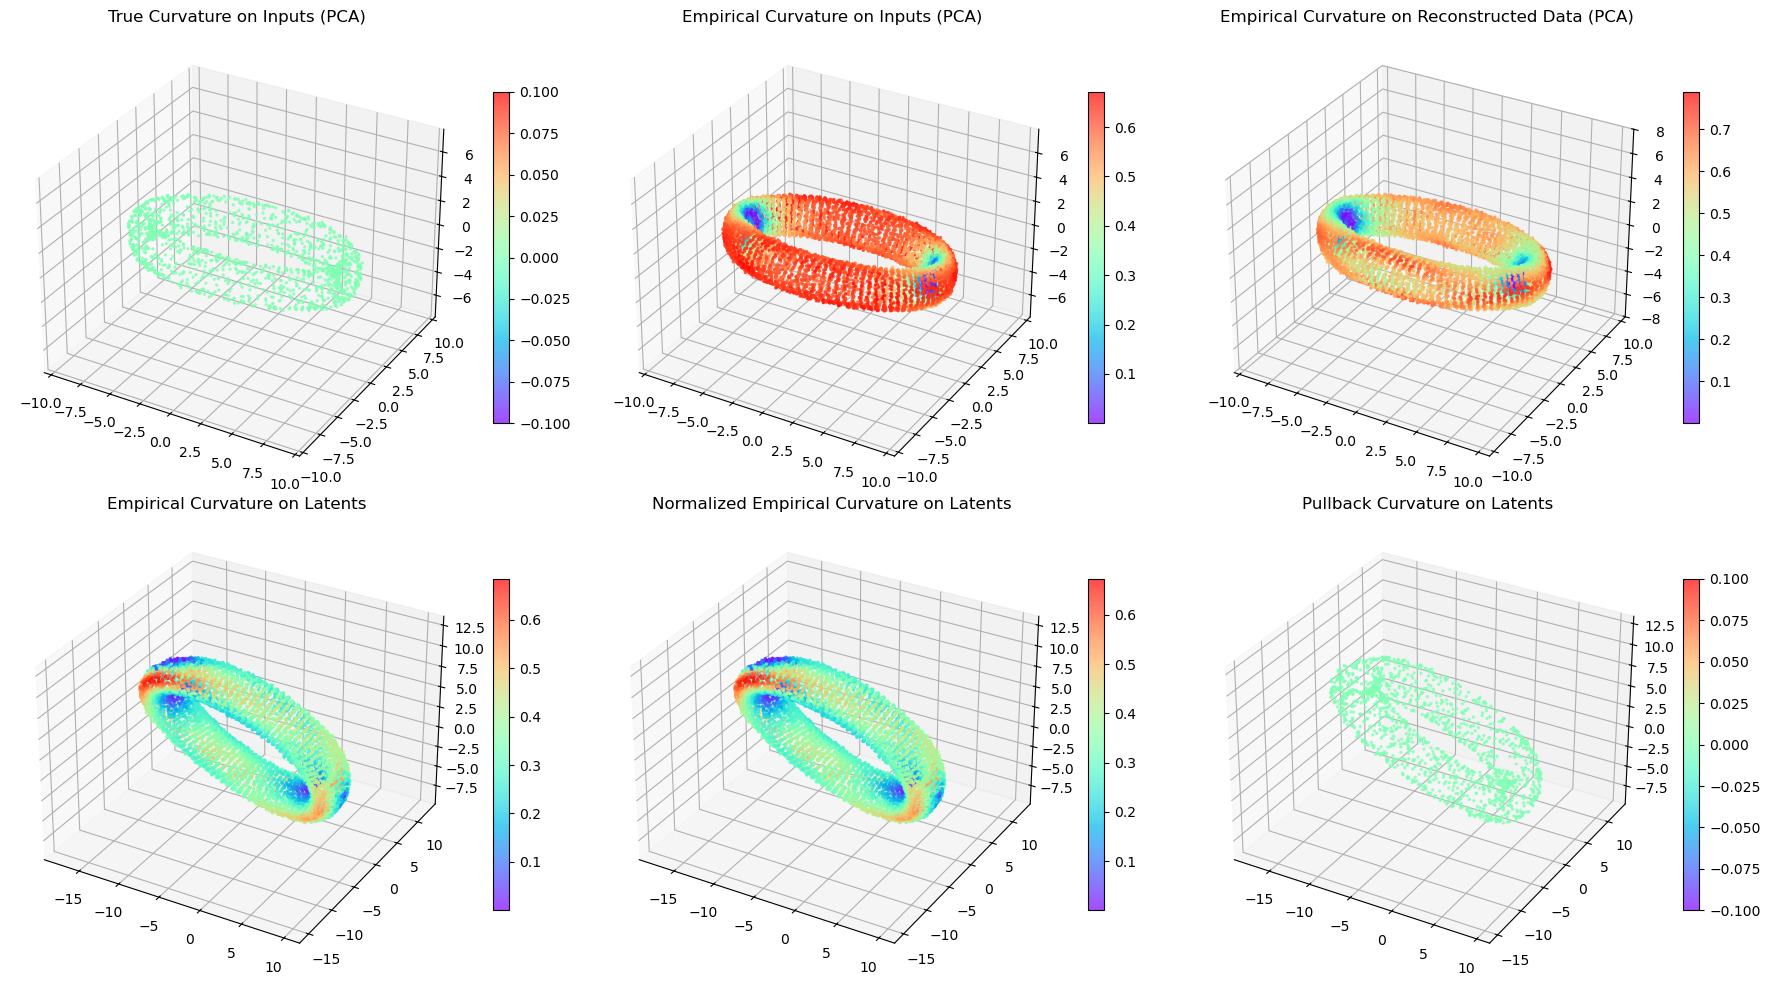

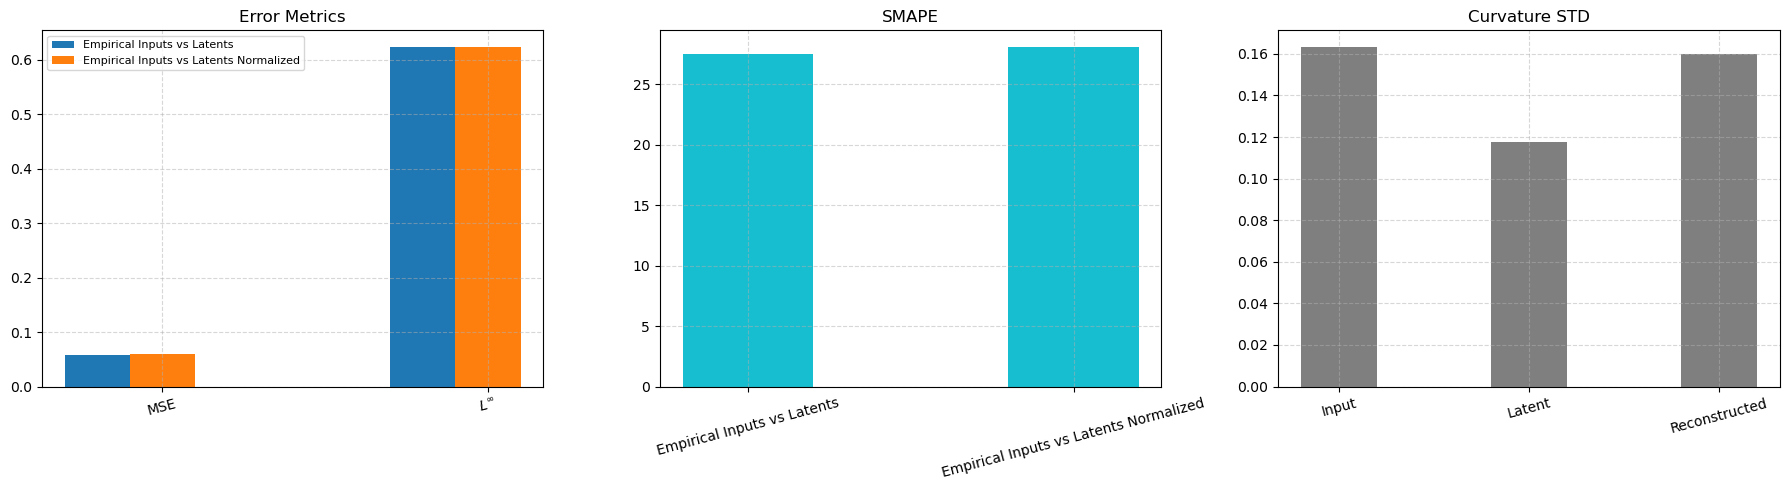

Execution time exp00_torus: 62.4477 seconds

Running exp01_torus. 
Description: alpha=1, gamma=1, deformation_amp=3, dim_topo_loss=0
--------------------------------------------------------------------------------------


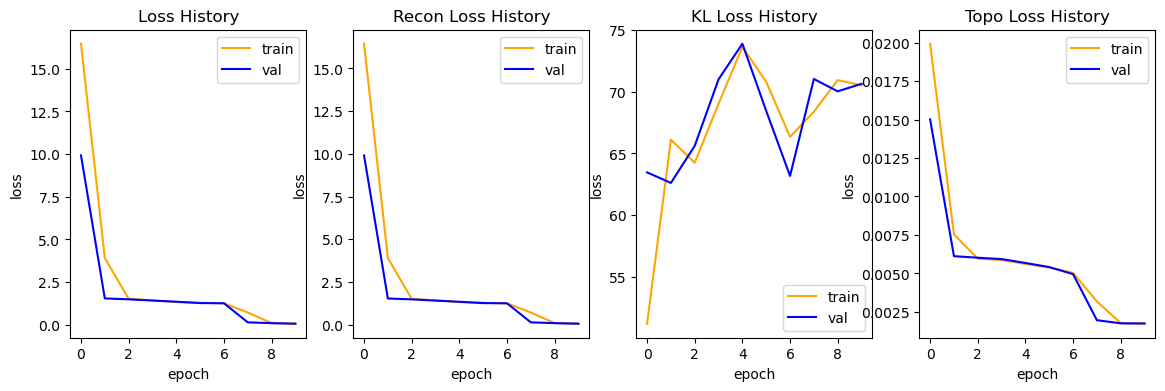

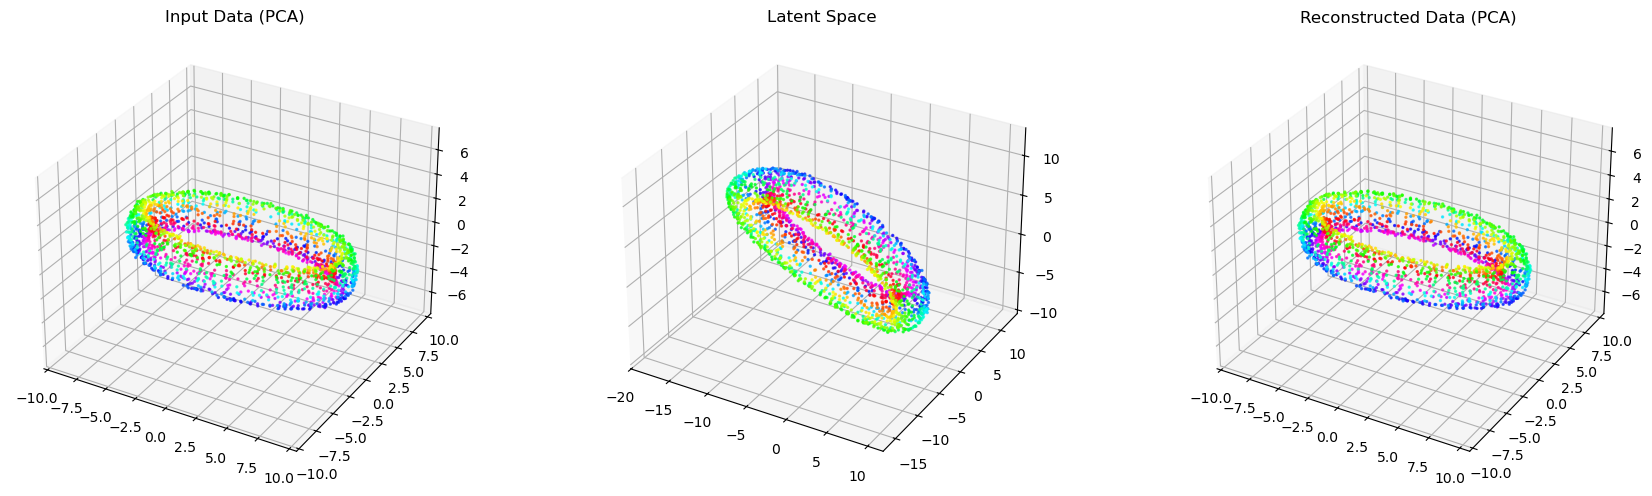

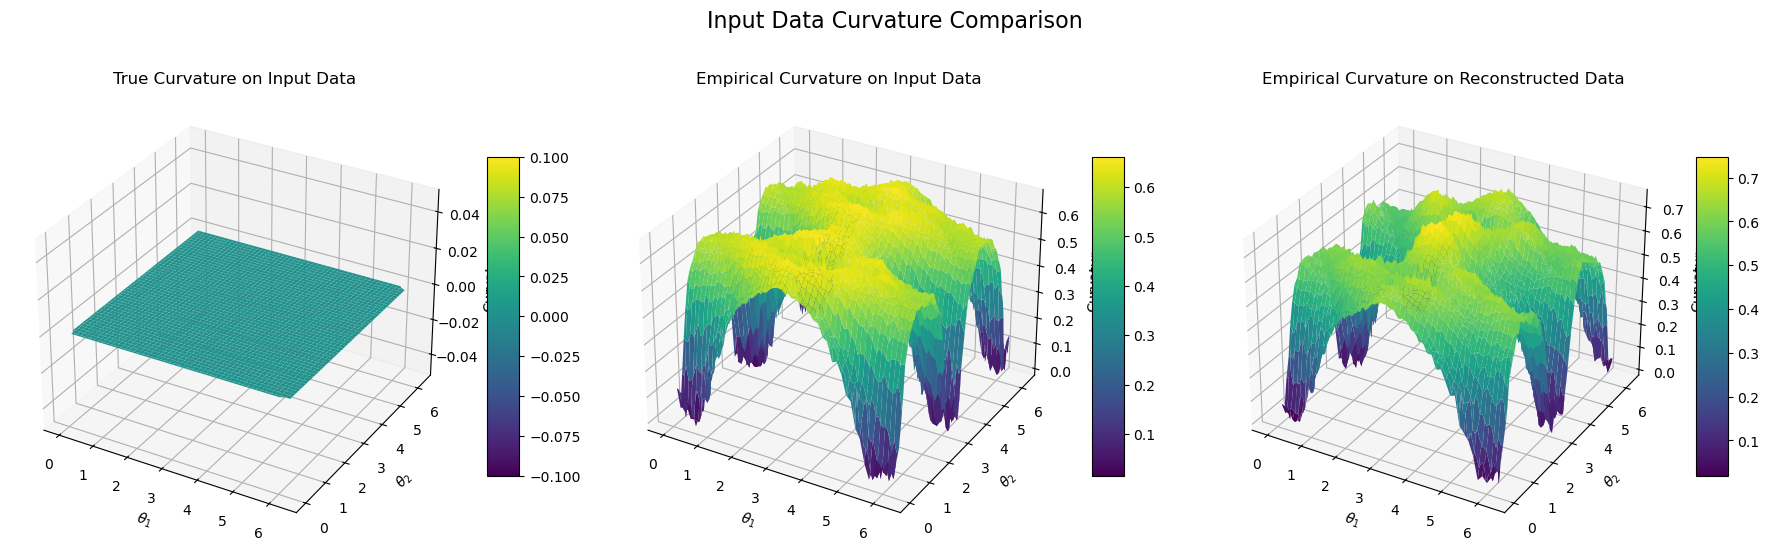

In [ ]:
run_experiment(all_configs=all_configs)